In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='husl')

df = pd.read_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\retail_clean.csv'
)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Daily sales shape: (604, 2)
        date     sales
0 2009-12-01  44048.69
1 2009-12-02  52941.99
2 2009-12-03  67479.08
3 2009-12-04  34064.41
4 2009-12-05   9803.05


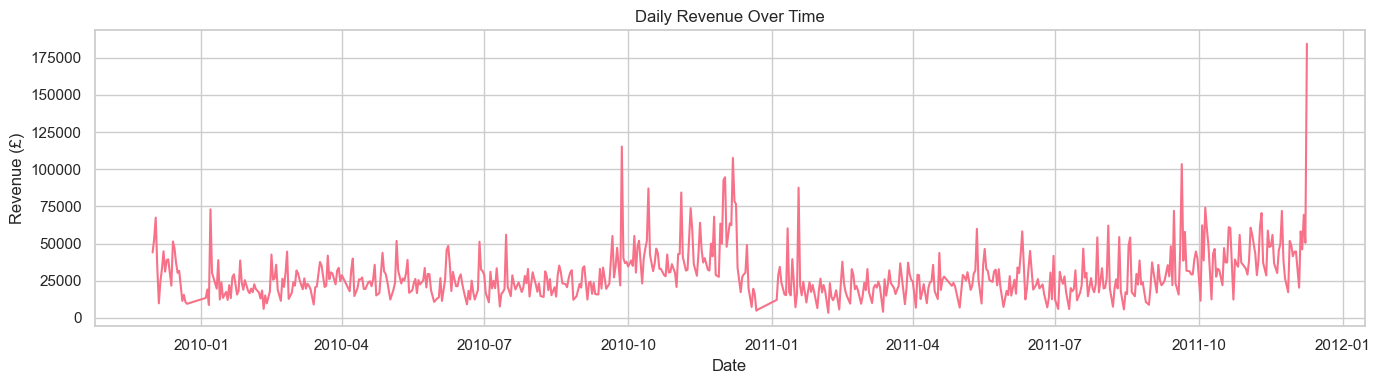

In [3]:
daily_sales = df.groupby(
    df['InvoiceDate'].dt.date
)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['date', 'sales']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.sort_values('date').reset_index(drop=True)

print(f"Daily sales shape: {daily_sales.shape}")
print(daily_sales.head())

plt.figure(figsize=(14,4))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Daily Revenue Over Time')
plt.xlabel('Date'); plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/07_daily_sales.png', dpi=150)
plt.show()

In [4]:
date_range = pd.date_range(
    start=daily_sales['date'].min(),
    end=daily_sales['date'].max(), freq='D'
)
print(f"Expected days: {len(date_range)}")
print(f"Actual days: {len(daily_sales)}")
print(f"Missing days: {len(date_range) - len(daily_sales)}")

daily_sales = daily_sales.set_index('date')\
    .reindex(date_range, fill_value=0).reset_index()
daily_sales.columns = ['date', 'sales']
print(f"\nAfter filling: {daily_sales.shape}")

Expected days: 739
Actual days: 604
Missing days: 135

After filling: (739, 2)


ADF Statistic: -2.1148
p-value: 0.2386
→ Series is NOT stationary (has trend/seasonality)


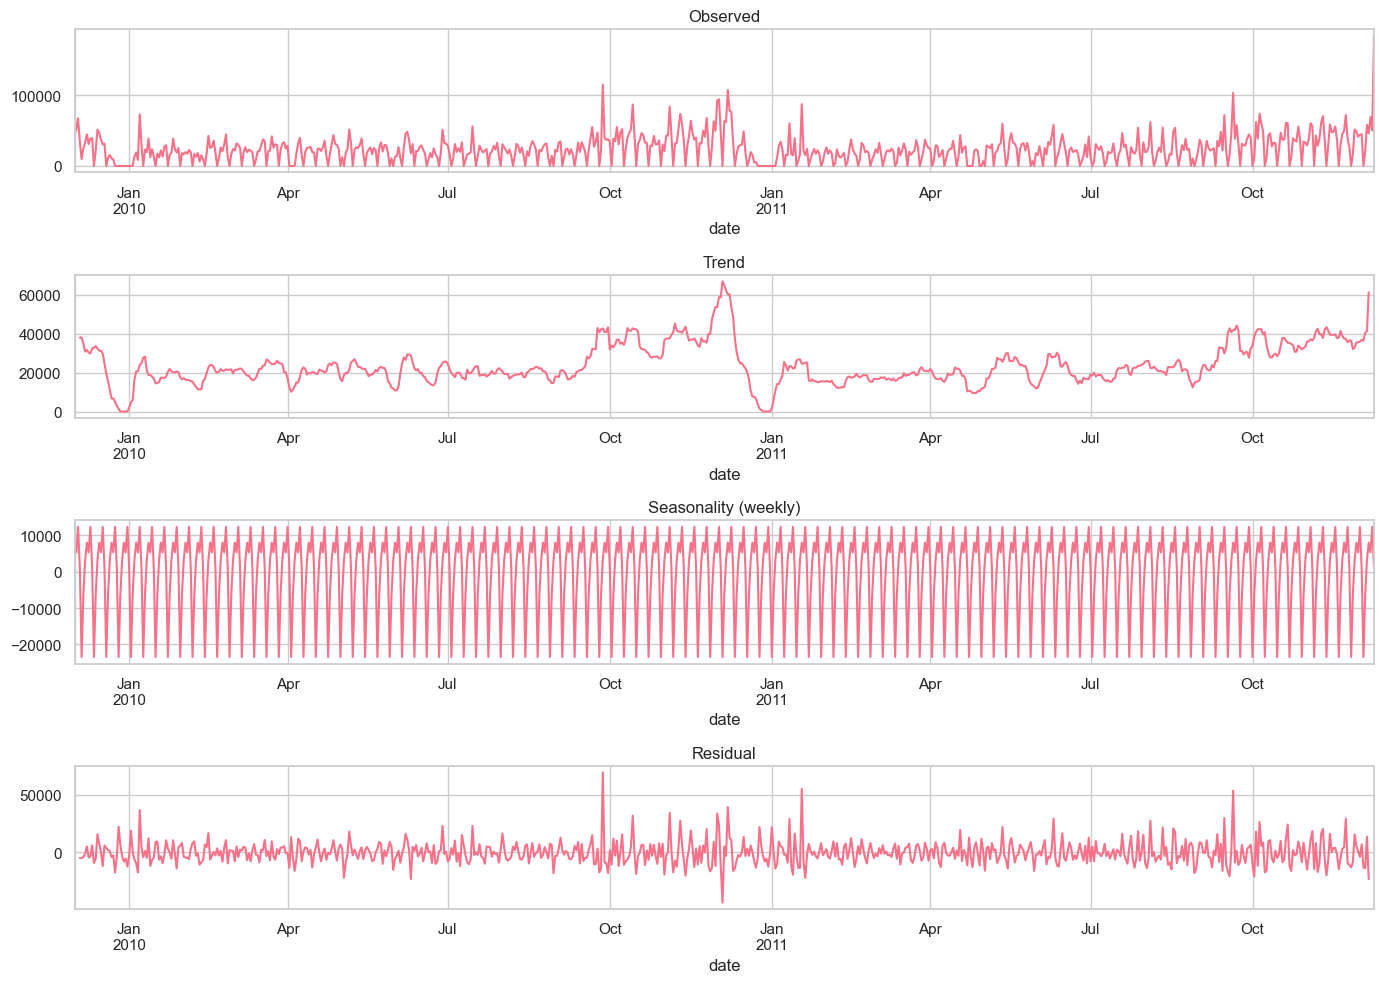

In [5]:
result = adfuller(daily_sales['sales'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("→ Series is stationary")
else:
    print("→ Series is NOT stationary (has trend/seasonality)")

decomposition = seasonal_decompose(
    daily_sales.set_index('date')['sales'],
    model='additive', period=7
)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality (weekly)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('../reports/08_decomposition.png', dpi=150)
plt.show()

In [6]:
daily_sales.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\daily_sales.csv',
    index=False
)